# Chapter 6 Companion — Variational Quantum Algorithms

Runnable companions to the worked examples in
[`docs/06_variational_quantum_algorithms`](../docs/06_variational_quantum_algorithms):

- [`01_vqe_fundamentals.md`](../docs/06_variational_quantum_algorithms/01_vqe_fundamentals.md)
- [`03_parameter_shift_gradient.md`](../docs/06_variational_quantum_algorithms/03_parameter_shift_gradient.md)
- [`04_qaoa.md`](../docs/06_variational_quantum_algorithms/04_qaoa.md)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize

np.set_printoptions(precision=6, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(*ops):
    out = np.array([[1]], dtype=complex)
    for o in ops:
        out = np.kron(out, o)
    return out

## Example 1 — The H₂ VQE landscape `E(θ)`

*Docs: `01_vqe_fundamentals.md`, "Worked Example: H₂ VQE by Hand".* The 2-qubit reduced H₂
Hamiltonian at `R = 0.735 Å`:

`H = −1.052373 I + 0.397937 Z₁ − 0.397937 Z₂ − 0.011280 Z₁Z₂ + 0.180931 X₁X₂`

Exact spectrum `{−1.857275, −1.244585, −0.882722, −0.224911}` Ha. The one-parameter ansatz
`|ψ(θ)⟩ = cos(θ/2)|01⟩ + sin(θ/2)|10⟩` gives
`E(θ) = −1.041093 + 0.795875 cos θ + 0.180931 sin θ`, whose minimum `−1.857275` Ha at
`θ* ≈ 3.3651` equals `E₀` exactly; `E(π) = −1.836968` Ha is Hartree–Fock. An
under-expressive ansatz in the `{|00⟩,|11⟩}` block bottoms out at `−1.244585` Ha — above
`E₀`, as the variational principle demands.

exact spectrum (Ha): [-1.857274 -1.244584 -0.882722 -0.224912]
E(θ*=3.3651) = -1.857274 Ha  (docs: -1.857275 at θ*≈3.3651)
E(π) = -1.836967 Ha = Hartree-Fock  (docs: -1.836968)
under-expressive ansatz minimum: -1.244583 Ha  (docs: -1.244585, 0.61 Ha above E0)


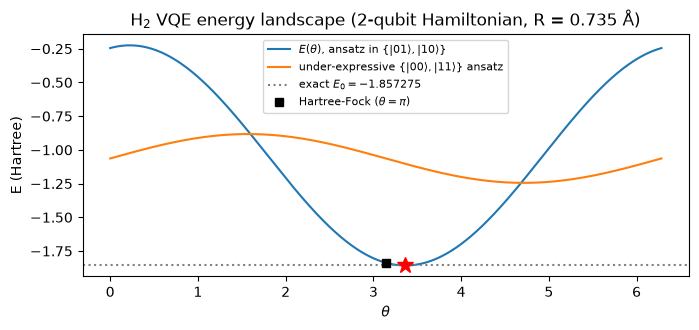

total energy with nuclear repulsion: -1.137305015851846 Ha (docs: -1.137306)


In [2]:
coeffs = {"I": -1.052373, "Z1": 0.397937, "Z2": -0.397937, "ZZ": -0.011280, "XX": 0.180931}
H_h2 = (coeffs["I"] * kron(I2, I2) + coeffs["Z1"] * kron(Z, I2) + coeffs["Z2"] * kron(I2, Z)
        + coeffs["ZZ"] * kron(Z, Z) + coeffs["XX"] * kron(X, X))

evals = np.linalg.eigvalsh(H_h2)
print("exact spectrum (Ha):", evals)
assert np.allclose(evals, [-1.857275, -1.244585, -0.882722, -0.224911], atol=1e-5)
E0 = evals[0]

def ansatz_state(theta):
    '''cos(θ/2)|01> + sin(θ/2)|10>  (index order q1 q2)'''
    psi = np.zeros(4, dtype=complex)
    psi[0b01] = np.cos(theta/2)
    psi[0b10] = np.sin(theta/2)
    return psi

def E(theta):
    psi = ansatz_state(theta)
    return np.real(psi.conj() @ H_h2 @ psi)

E_closed = lambda th: -1.041093 + 0.795875*np.cos(th) + 0.180931*np.sin(th)
ths = np.linspace(0, 2*np.pi, 400)
assert np.allclose([E(t) for t in ths], E_closed(ths), atol=1e-6)

theta_star = np.pi + np.arctan(0.180931/0.795875)
print(f"E(θ*={theta_star:.4f}) = {E(theta_star):.6f} Ha  (docs: -1.857275 at θ*≈3.3651)")
print(f"E(π) = {E(np.pi):.6f} Ha = Hartree-Fock  (docs: -1.836968)")
assert np.isclose(E(theta_star), -1.857275, atol=1e-5)
assert np.isclose(E(np.pi), -1.836968, atol=1e-5)

# under-expressive ansatz: cos(θ/2)|00> + sin(θ/2)|11>
def E_bad(theta):
    psi = np.zeros(4, dtype=complex)
    psi[0b00], psi[0b11] = np.cos(theta/2), np.sin(theta/2)
    return np.real(psi.conj() @ H_h2 @ psi)
E_bad_min = min(E_bad(t) for t in ths)
print(f"under-expressive ansatz minimum: {E_bad_min:.6f} Ha  (docs: -1.244585, 0.61 Ha above E0)")
assert np.isclose(E_bad_min, -1.244585, atol=1e-4)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ths, E_closed(ths), label=r"$E(\theta)$, ansatz in $\{|01\rangle,|10\rangle\}$")
ax.plot(ths, [E_bad(t) for t in ths], label=r"under-expressive $\{|00\rangle,|11\rangle\}$ ansatz")
ax.axhline(E0, color="gray", ls=":", label=r"exact $E_0 = -1.857275$")
ax.plot(theta_star, E(theta_star), "r*", ms=12)
ax.plot(np.pi, E(np.pi), "ks", ms=6, label=r"Hartree-Fock ($\theta=\pi$)")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("E (Hartree)")
ax.set_title(r"H$_2$ VQE energy landscape (2-qubit Hamiltonian, R = 0.735 Å)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("total energy with nuclear repulsion:", E(theta_star) + 0.719969, "Ha (docs: -1.137306)")

## Example 2 — Parameter-shift rule vs. finite differences

*Docs: `03_parameter_shift_gradient.md`, "Worked Example".* For `f(θ) = ⟨0|Ry(θ)†Z Ry(θ)|0⟩
= cos θ`:

- parameter shift at `θ = π/3`: `[f(θ+π/2) − f(θ−π/2)]/2 = −0.866` — **exactly** `−sin(π/3)`;
- central finite difference with `ε = 0.1` errs by `≈ 0.0014`, matching the truncation term
  `ε²·|f‴|/6`;
- the quantum Fisher information for this circuit is constant, `F = 1`.

parameter-shift gradient at π/3: -0.866025, exact -sin(π/3) = -0.866025
finite difference (ε=0.1): -0.86458, error = 0.0014 (docs: ≈0.0014; predicted ε²|f'''|/6 = 0.0014)
QFIM over θ: min = 1.000000, max = 1.000000 (docs: constant F = 1)


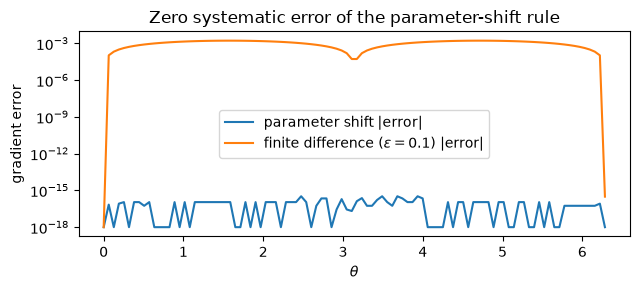

In [3]:
def Ry(t): return np.array([[np.cos(t/2), -np.sin(t/2)], [np.sin(t/2), np.cos(t/2)]], dtype=complex)

def f(theta):
    psi = Ry(theta) @ np.array([1, 0], dtype=complex)
    return np.real(psi.conj() @ Z @ psi)

theta0 = np.pi/3
ps_grad = (f(theta0 + np.pi/2) - f(theta0 - np.pi/2)) / 2
exact = -np.sin(theta0)
print(f"parameter-shift gradient at π/3: {ps_grad:.6f}, exact -sin(π/3) = {exact:.6f}")
assert np.isclose(ps_grad, exact, atol=1e-12)     # exact, no truncation error

eps = 0.1
fd_grad = (f(theta0 + eps) - f(theta0 - eps)) / (2*eps)
err = abs(fd_grad - exact)
pred = eps**2 * np.sin(theta0) / 6
print(f"finite difference (ε=0.1): {fd_grad:.5f}, error = {err:.4f} "
      f"(docs: ≈0.0014; predicted ε²|f'''|/6 = {pred:.4f})")
assert np.isclose(fd_grad, -0.86458, atol=1e-4) and np.isclose(err, pred, atol=2e-4)

# QFIM: F = 4[<∂ψ|∂ψ> - |<ψ|∂ψ>|²] = 1 for Ry(θ)|0>
def qfim(theta, d=1e-6):
    psi = Ry(theta) @ np.array([1, 0], dtype=complex)
    dpsi = (Ry(theta + d) - Ry(theta - d)) @ np.array([1, 0], dtype=complex) / (2*d)
    return 4 * np.real(dpsi.conj() @ dpsi - abs(psi.conj() @ dpsi)**2)
Fs = [qfim(t) for t in np.linspace(0, 2*np.pi, 25)]
print("QFIM over θ: min = %.6f, max = %.6f (docs: constant F = 1)" % (min(Fs), max(Fs)))
assert np.allclose(Fs, 1, atol=1e-6)

# parameter-shift is exact at every θ; finite difference is not
ths = np.linspace(0, 2*np.pi, 100)
ps_err = [abs((f(t+np.pi/2) - f(t-np.pi/2))/2 + np.sin(t)) for t in ths]
fd_err = [abs((f(t+eps) - f(t-eps))/(2*eps) + np.sin(t)) for t in ths]
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.semilogy(ths, np.maximum(ps_err, 1e-18), label="parameter shift |error|")
ax.semilogy(ths, np.maximum(fd_err, 1e-18), label=r"finite difference ($\varepsilon=0.1$) |error|")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("gradient error")
ax.set_title("Zero systematic error of the parameter-shift rule")
ax.legend(); fig.tight_layout(); plt.show()

## Example 3 — QAOA MaxCut on the triangle + pendant-edge graph

*Docs: `04_qaoa.md`, "Worked Example".* Graph: vertices `{1,2,3,4}`, edges
`{(1,2),(2,3),(3,1),(1,4)}`, `MaxCut = 3`. Depth-1 QAOA with
`|ψ(γ,β)⟩ = e^{−iβΣX} e^{−iγH_C} |+⟩⁴`:

- `F₁(0.4, 0.4) = 2.593` (ratio 0.864),
- optimum `(γ*, β*) ≈ (0.652, 1.901)` with `F₁* = 2.713` (ratio 0.905),
- sampling probabilities: the four balanced optimal cuts at `0.132` each, the two singleton
  cuts at `0.106` each — an optimal cut is sampled with probability `≈ 0.74` per shot.

MaxCut value = largest eigenvalue of H_C = 3.0
F1(0.4, 0.4) = 2.593  ratio = 0.864  (docs: 2.593, 0.864)
optimum (γ*, β*) = (0.653, 1.900),  F1* = 2.7135, ratio = 0.904
  (docs: (0.652, 1.901), 2.713, 0.905)
balanced optimal cuts: ['1100: 0.132', '1010: 0.132', '0101: 0.132', '0011: 0.132'] (docs: 0.132)
singleton cuts:        ['1000: 0.105', '0111: 0.105'] (docs: 0.106)
P(sample an optimal cut) = 0.738  (docs: ≈ 0.74)


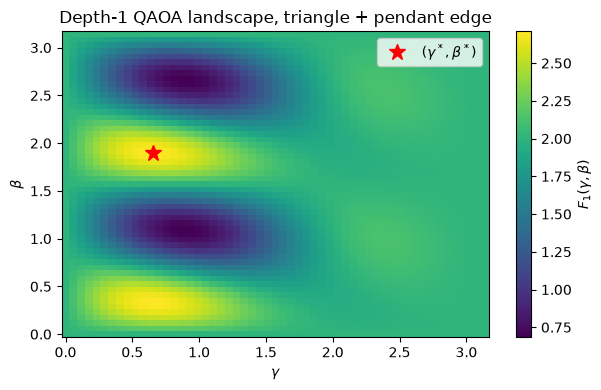

In [4]:
n = 4
edges = [(0, 1), (1, 2), (2, 0), (0, 3)]          # 0-indexed version of the docs' graph

def op_on(single, i):
    return kron(*[single if k == i else I2 for k in range(n)])

H_C = np.zeros((2**n, 2**n), dtype=complex)
for (i, j) in edges:
    H_C += 0.5 * (np.eye(2**n) - op_on(Z, i) @ op_on(Z, j))
print("MaxCut value = largest eigenvalue of H_C =", np.linalg.eigvalsh(H_C)[-1].real)
assert np.isclose(np.linalg.eigvalsh(H_C)[-1], 3)

X_sum = sum(op_on(X, i) for i in range(n))
plus_state = np.ones(2**n, dtype=complex) / 2**(n/2)

def qaoa_state(gamma, beta):
    psi = expm(-1j * gamma * H_C) @ plus_state
    return expm(-1j * beta * X_sum) @ psi

def F1(gamma, beta):
    psi = qaoa_state(gamma, beta)
    return np.real(psi.conj() @ H_C @ psi)

print(f"F1(0.4, 0.4) = {F1(0.4, 0.4):.3f}  ratio = {F1(0.4,0.4)/3:.3f}  (docs: 2.593, 0.864)")
assert np.isclose(F1(0.4, 0.4), 2.593, atol=1e-3)

res = minimize(lambda v: -F1(*v), x0=[0.65, 1.9], method="Nelder-Mead",
               options={"xatol": 1e-8, "fatol": 1e-10})
g_s, b_s = res.x
F1_star = -res.fun
print(f"optimum (γ*, β*) = ({g_s:.3f}, {b_s:.3f}),  F1* = {F1_star:.4f}, ratio = {F1_star/3:.3f}")
print("  (docs: (0.652, 1.901), 2.713, 0.905)")
assert np.isclose(F1_star, 2.7135, atol=1e-3)
assert np.allclose([g_s, b_s], [0.652, 1.901], atol=5e-3)

# sampling distribution at the optimum
psi = qaoa_state(g_s, b_s)
probs = np.abs(psi)**2
def cut_value(bits):
    s = [(bits >> (n - 1 - k)) & 1 for k in range(n)]   # bit k = vertex k (docs order)
    return sum(1 for (i, j) in edges if s[i] != s[j])

balanced = [0b1100, 0b1010, 0b0101, 0b0011]
singleton = [0b1000, 0b0111]
print("balanced optimal cuts:", [f"{b:04b}: {probs[b]:.3f}" for b in balanced], "(docs: 0.132)")
print("singleton cuts:       ", [f"{b:04b}: {probs[b]:.3f}" for b in singleton], "(docs: 0.106)")
p_opt = sum(probs[b] for b in range(2**n) if cut_value(b) == 3)
print(f"P(sample an optimal cut) = {p_opt:.3f}  (docs: ≈ 0.74)")
assert all(np.isclose(probs[b], 0.132, atol=1.5e-3) for b in balanced)
assert all(np.isclose(probs[b], 0.106, atol=1.5e-3) for b in singleton)
assert np.isclose(p_opt, 0.738, atol=3e-3)

# landscape heat map
gs = np.linspace(0, np.pi, 55); bs = np.linspace(0, np.pi, 55)
land = np.array([[F1(g, b) for g in gs] for b in bs])
fig, ax = plt.subplots(figsize=(6.2, 4))
im = ax.pcolormesh(gs, bs, land, shading="auto", cmap="viridis")
ax.plot(g_s, b_s % np.pi, "r*", ms=12, label=r"$(\gamma^*, \beta^*)$")
fig.colorbar(im, label=r"$F_1(\gamma,\beta)$")
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel(r"$\beta$")
ax.set_title("Depth-1 QAOA landscape, triangle + pendant edge")
ax.legend(); fig.tight_layout(); plt.show()

## Example 4 — QAOA on the 5-cycle: the closed form `F₁* = 3.75`

*Docs: `04_qaoa.md`, Exercise 1.* For `C₅` (odd cycle), `MaxCut = 4`. The triangle-free
degree-2 formula gives `F₁ = 5[½ + ¼ sin(4β) sin(2γ)]`, maximized at `(γ*, β*) = (π/4, π/8)`
with `F₁* = 3.75` — approximation ratio `0.9375`. We confirm by statevector simulation.

MaxCut(C5) = 4.0  (docs: 4)
F1(π/4, π/8) statevector = 3.7500, closed form = 3.7500  (docs: 3.7500)
approximation ratio = 0.9375  (docs: 0.9375; 3-regular worst case: 0.6924)


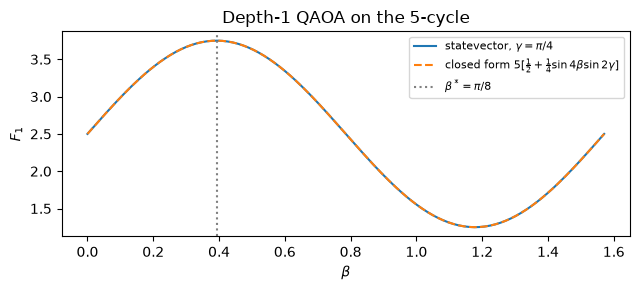

In [5]:
n5 = 5
edges5 = [(i, (i + 1) % n5) for i in range(n5)]

def op5(single, i):
    return kron(*[single if k == i else I2 for k in range(n5)])

H_C5 = np.zeros((2**n5, 2**n5), dtype=complex)
for (i, j) in edges5:
    H_C5 += 0.5 * (np.eye(2**n5) - op5(Z, i) @ op5(Z, j))
X5 = sum(op5(X, i) for i in range(n5))
plus5 = np.ones(2**n5, dtype=complex) / 2**(n5/2)

def F1_c5(gamma, beta):
    psi = expm(-1j * beta * X5) @ (expm(-1j * gamma * H_C5) @ plus5)
    return np.real(psi.conj() @ H_C5 @ psi)

maxcut5 = np.linalg.eigvalsh(H_C5)[-1].real
print("MaxCut(C5) =", maxcut5, " (docs: 4)")
assert np.isclose(maxcut5, 4)

val = F1_c5(np.pi/4, np.pi/8)
closed = 5 * (0.5 + 0.25 * np.sin(4*np.pi/8) * np.sin(2*np.pi/4))
print(f"F1(π/4, π/8) statevector = {val:.4f}, closed form = {closed:.4f}  (docs: 3.7500)")
print(f"approximation ratio = {val/4:.4f}  (docs: 0.9375; 3-regular worst case: 0.6924)")
assert np.isclose(val, 3.75, atol=1e-6) and np.isclose(closed, 3.75)

# sweep the closed-form landscape along β at γ = π/4
bs = np.linspace(0, np.pi/2, 200)
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(bs, [F1_c5(np.pi/4, b) for b in bs], label=r"statevector, $\gamma = \pi/4$")
ax.plot(bs, 5*(0.5 + 0.25*np.sin(4*bs)*np.sin(np.pi/2)), "--",
        label=r"closed form $5[\frac{1}{2} + \frac{1}{4}\sin 4\beta \sin 2\gamma]$")
ax.axvline(np.pi/8, color="gray", ls=":", label=r"$\beta^* = \pi/8$")
ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$F_1$")
ax.set_title("Depth-1 QAOA on the 5-cycle")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()